| Roll No.| Subject Code | Assignment No. |
|:-------:|:------------:|:--------------:|
| 2650026 | CS69101      | Lab 2          |

Implement a Binary Search Tree (BST) with the following operations:

In [1]:
import copy
import random
import math
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import sys
import pandas as pd

sys.setrecursionlimit(100000) # Fix to avoid RecursionError

iterations = 0 # Global Variable to count iterations during a run

In [2]:
class BST_Node:
    def __init__(self):
        self.lchild = None
        self.rchild = None
        self.value = None
        self.parent = None

In [3]:
def BST_Insert(value, root_node:BST_Node | None = None) -> BST_Node:
    assert value != None, "Value cannot be None"
    y = None
    x = root_node
    global iterations
    while x is not None:
        iterations += 1
        y = x
        if value < x.value: # type: ignore
            x = x.lchild # type: ignore
        else:
            x = x.rchild # type: ignore
    new_node = BST_Node()
    new_node.value = value
    new_node.parent = y # type: ignore
    if y is None:
        root_node = new_node
    elif value < y.value: # type: ignore
        y.lchild = new_node # type: ignore
    else:
        y.rchild = new_node # type: ignore
    return root_node # type: ignore

In [4]:
def BST_inorder(root_node:BST_Node | None = None):
    global iterations
    if root_node is None:
        return
    iterations += 1 # type: ignore
    BST_inorder(root_node.lchild)
    print(root_node.value, end=',')
    BST_inorder(root_node.rchild)

def BST_preorder(root_node:BST_Node | None = None):
    global iterations
    if root_node is None:
        return
    iterations += 1 # type: ignore
    print(root_node.value, end=',')
    BST_preorder(root_node.lchild)
    BST_preorder(root_node.rchild)

def BST_postorder(root_node:BST_Node | None = None):
    global iterations
    if root_node is None:
        return
    iterations += 1 # type: ignore
    BST_postorder(root_node.lchild)
    BST_postorder(root_node.rchild)
    print(root_node.value, end=',')

In [5]:
def BST_minimum(root_node:BST_Node | None = None) -> BST_Node | None:
    global iterations
    if root_node is None:
        return None
    while root_node.lchild is not None:
        iterations += 1 # type: ignore
        root_node = root_node.lchild
    return root_node

def BST_maximum(root_node:BST_Node | None = None) -> BST_Node | None:
    global iterations
    if root_node is None:
        return None
    while root_node.rchild is not None:
        iterations += 1 # type: ignore
        root_node = root_node.rchild
    return root_node

In [6]:
def BST_successor(node:BST_Node | None = None) -> BST_Node | None:
    global iterations
    if node is None:
        return None
    if node.rchild is not None:
        return BST_minimum(node.rchild)
    y = node.parent
    while (y is not None) and (y.rchild == node):
        iterations += 1 # type: ignore
        node = y
        y = y.parent
    return y

def BST_predecessor(node:BST_Node | None = None) -> BST_Node | None:
    global iterations
    if node is None:
        return None
    if node.lchild is not None:
        return BST_maximum(node.lchild)
    y = node.parent # type: ignore
    while (y is not None) and (y.lchild == node):
        iterations += 1
        node = y
        y = y.parent
    return y

In [7]:
def BST_Search(value, root_node:BST_Node | None = None) -> BST_Node | None:
    global iterations
    if root_node is None:
        return None
    iterations += 1 # type: ignore
    if value == root_node.value:
        return root_node
    elif value < root_node.value:
        return BST_Search(value, root_node.lchild)
    else:
        return BST_Search(value, root_node.rchild)

In [8]:
def BST_Transplant(root_node:BST_Node | None = None, target_node:BST_Node | None = None, replacement_node:BST_Node | None = None) -> BST_Node | None:
    global iterations
    iterations += 1 # type: ignore
    
    # None Handling
    if root_node is None:
        return None
    if target_node is None:
        return root_node

    # Transplantation
    if target_node.parent is None:
        root_node = replacement_node
    elif target_node == target_node.parent.lchild:
        target_node.parent.lchild = replacement_node
    else:
        target_node.parent.rchild = replacement_node
    if replacement_node is not None:
        replacement_node.parent = target_node.parent
    
    return root_node

In [9]:
def BST_Delete(root_node:BST_Node | None = None, target_node:BST_Node | None = None) -> BST_Node | None:
    global iterations
    iterations += 1 # type: ignore
    
    # None Handling
    if root_node is None:
        return None
    if target_node is None:
        return root_node

    # Deletion
    if target_node.lchild is None:
        root_node = BST_Transplant(root_node, target_node, target_node.rchild)
    elif target_node.rchild is None:
        root_node = BST_Transplant(root_node, target_node, target_node.lchild)
    else:
        successor_node = BST_minimum(target_node.rchild)
        if successor_node.parent != target_node: # type: ignore
            root_node = BST_Transplant(root_node, successor_node, successor_node.rchild) # type: ignore
            successor_node.rchild = target_node.rchild # type: ignore
            successor_node.rchild.parent = successor_node # type: ignore
        root_node = BST_Transplant(root_node, target_node, successor_node)
        successor_node.lchild = target_node.lchild   # type: ignore
        successor_node.lchild.parent = successor_node # type: ignore

In [10]:
def BST_Height(root_node:BST_Node | None = None) -> int:
    global iterations
    if root_node is None:
        return 0
    iterations += 1 # type: ignore
    left_height = BST_Height(root_node.lchild)
    right_height = BST_Height(root_node.rchild)
    return max(left_height, right_height) + 1

# Q1.

Insert the keys [50,30,70,20,40,60,80,10] into your BST. Print the inorder, preorder and postorder traversals. Verify that the inorder traversal is in sorted order. Search for one key that is present and one key that is absent in the tree and show the output.

In [11]:
# Given data
arr = [50,30,70,20,40,60,80,10]

In [12]:
root_node = None
iterations = 0 # Reset iteration count before insertions
iter_arr = [] # To store iteration counts for each insertion
for i in arr:
    iterations = 0 # Reset iteration count for each insertion
    root_node = BST_Insert(i, root_node)
    iter_arr.append(iterations) # Store iteration count for each insertion

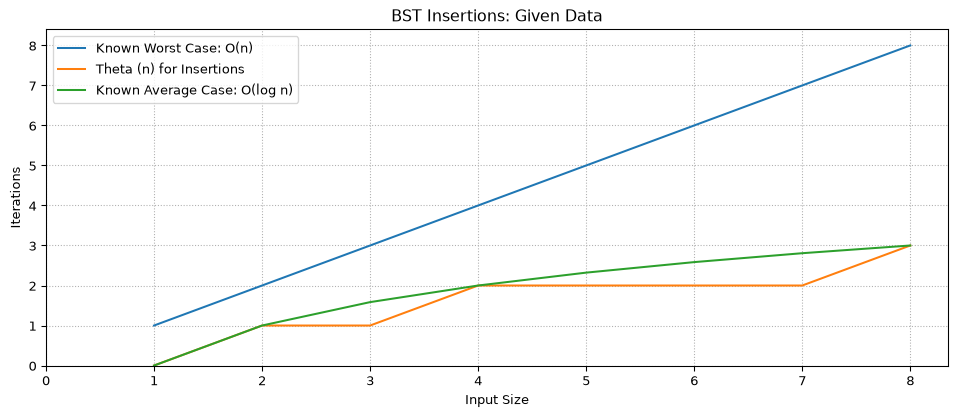

In [13]:
# Plot Graph for Iterations (for Insertion) vs Tree Size
figure(figsize=(12, 4.5), dpi=97)
x = [i+1 for i in range(len(arr))]
y = iter_arr[:]

plt.plot(x, x, label="Known Worst Case: O(n)")
plt.plot(x, y, label="Theta (n) for Insertions")
plt.plot(x, [math.log2(i) for i in x], label="Known Average Case: O(log n)")

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.title("BST Insertions: Given Data")
plt.grid(visible=True, linestyle=':')
plt.show()

In [18]:
results_insertions_given = pd.DataFrame({'Input Size': x, 'Iterations (Given Data)': y})

In [19]:
results_insertions_given

,Input Size,Iterations (Given Data)
0,1,0
1,2,1
2,3,1
3,4,2
4,5,2
5,6,2
6,7,2
7,8,3


In [20]:
results_insertions_given.to_csv('2650026_lab2_data_given.csv', index=False)

In [21]:
iter_arr = []

iterations = 0 # Reset iteration count before traversals
BST_inorder(root_node)
print() # New line after inorder traversal
iter_arr.append(iterations)

iterations = 0 # Reset iteration count before traversals
BST_preorder(root_node)
print() # New line after preorder traversal
iter_arr.append(iterations)

iterations = 0 # Reset iteration count before traversals
BST_postorder(root_node)
print() # New line after postorder traversal
iter_arr.append(iterations)

10,20,30,40,50,60,70,80,
50,30,20,10,40,70,60,80,
10,20,40,30,60,80,70,50,


In [22]:
print("Iterations: (for Inorder, Preorder and Postorder Traversals, respectively)\n", iter_arr)

Iterations: (for Inorder, Preorder and Postorder Traversals, respectively)
 [8, 8, 8]


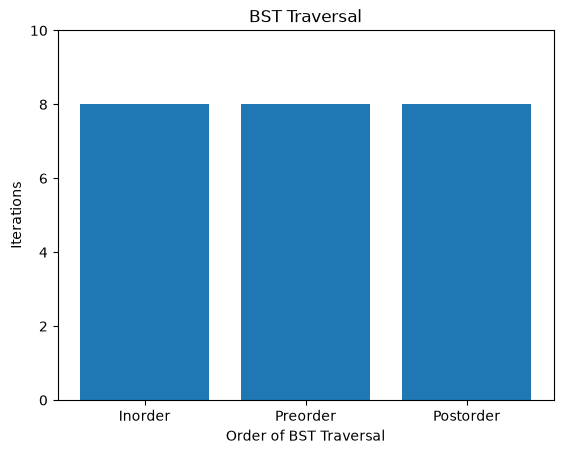

In [23]:
plt.bar(["Inorder", "Preorder", "Postorder"], iter_arr)
plt.ylim(top=10)
plt.xlabel("Order of BST Traversal")
plt.ylabel("Iterations")
plt.title("BST Traversal")
plt.show()

In [24]:
iter_arr = []
iterations = 0 # Reset iteration count before searching
BST_search_node = BST_Search(60, root_node)
if BST_search_node is not None:
    print(f"Found node with value: {BST_search_node.value}")
else:
    print("Node with value 60 not found.")
iter_arr.append(iterations)

Found node with value: 60


In [25]:
iterations = 0 # Reset iteration count before searching
BST_search_node = BST_Search(65, root_node)
if BST_search_node is not None:
    print(f"Found node with value: {BST_search_node.value}")
else:
    print("Node with value 65 not found.")
iter_arr.append(iterations)

Node with value 65 not found.


In [26]:
print("Iterations: (for searching 60 and 65 respectively)\n", iter_arr)

Iterations: (for searching 60 and 65 respectively)
 [3, 3]


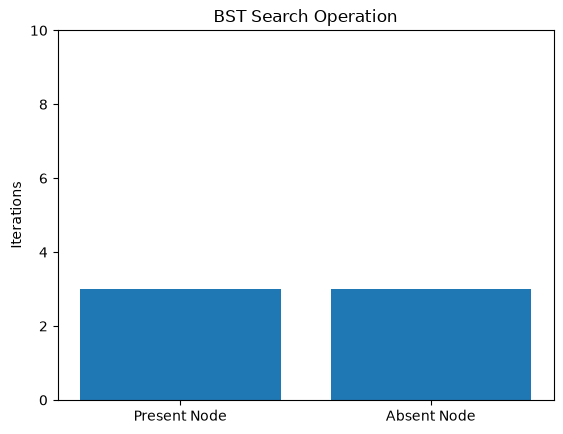

In [27]:
plt.bar(["Present Node", "Absent Node"], iter_arr)
plt.ylim(top=10)
plt.ylabel("Iterations")
plt.title("BST Search Operation")
plt.show()

# Q2.

Delete (i) a leaf node, (ii) a node with one child, and (iii) a node with two children. After each deletion, print the inorder traversal to confirm that the BST property is still satisfied.

In [28]:
# Function to list all leaf nodes in the BST
def BST_Leaf_Nodes(root_node:BST_Node | None = None):
    global iterations
    if root_node is None:
        return []
    if root_node.lchild is None and root_node.rchild is None:
        return [root_node.value]
    iterations += 1 # type: ignore
    return BST_Leaf_Nodes(root_node.lchild) + BST_Leaf_Nodes(root_node.rchild)

# Function to list all nodes with only one child in the BST
def BST_One_Child_Nodes(root_node:BST_Node | None = None):
    global iterations
    if root_node is None:
        return []
    if (root_node.lchild is None) != (root_node.rchild is None):  # XOR condition
        return [root_node.value] + BST_One_Child_Nodes(root_node.lchild) + BST_One_Child_Nodes(root_node.rchild)
    iterations += 1 # type: ignore
    return BST_One_Child_Nodes(root_node.lchild) + BST_One_Child_Nodes(root_node.rchild)

# Function to list all nodes with two children in the BST
def BST_Two_Children_Nodes(root_node:BST_Node | None = None):
    global iterations
    if root_node is None:
        return []
    if root_node.lchild is not None and root_node.rchild is not None:
        return [root_node.value] + BST_Two_Children_Nodes(root_node.lchild) + BST_Two_Children_Nodes(root_node.rchild)
    iterations += 1 # type: ignore
    return BST_Two_Children_Nodes(root_node.lchild) + BST_Two_Children_Nodes(root_node.rchild)

In [29]:
root_node_temp = copy.deepcopy(root_node)  # Create a deep copy of the original BST for deletion tests
iter_arr = [] # Reset iteration storage array

In [30]:
print("Leaf Nodes:", BST_Leaf_Nodes(root_node_temp))

Leaf Nodes: [10, 40, 60, 80]


In [31]:
# Deleting a leaf node
target_node = BST_Search(10, root_node_temp)
iterations = 0 # Reset iteration count before deletion
BST_Delete(root_node_temp, target_node)
print("Theta() for deleting node 10:", iterations)
iter_arr.append(iterations)
BST_inorder(root_node_temp)
print() # New line after inorder traversal

Theta() for deleting node 10: 2
20,30,40,50,60,70,80,


In [32]:
root_node_temp = copy.deepcopy(root_node)  # Create a deep copy of the original BST for deletion tests

In [33]:
print("One-Child Nodes:", BST_One_Child_Nodes(root_node_temp))

One-Child Nodes: [20]


In [34]:
# Deleting a node with one child
target_node = BST_Search(20, root_node_temp)
iterations = 0 # Reset iteration count before deletion
BST_Delete(root_node_temp, target_node)
print("Theta() for deleting node 20:", iterations)
iter_arr.append(iterations)
BST_inorder(root_node_temp)
print() # New line after inorder traversal

Theta() for deleting node 20: 2
10,30,40,50,60,70,80,


In [35]:
root_node_temp = copy.deepcopy(root_node)  # Create a deep copy of the original BST for deletion tests

In [36]:
print("Two-Children Nodes:", BST_Two_Children_Nodes(root_node_temp))

Two-Children Nodes: [50, 30, 70]


In [37]:
# Deleting a node with two children
target_node = BST_Search(30, root_node_temp)
iterations = 0 # Reset iteration count before deletion
BST_Delete(root_node_temp, target_node)
print("Theta() for deleting node 30:", iterations)
iter_arr.append(iterations)
BST_inorder(root_node_temp)
print() # New line after inorder traversal

Theta() for deleting node 30: 2
10,20,40,50,60,70,80,


In [38]:
print("Iterations: (for deleting leaf node, one-child node and two-children node respectively)\n", iter_arr)

Iterations: (for deleting leaf node, one-child node and two-children node respectively)
 [2, 2, 2]


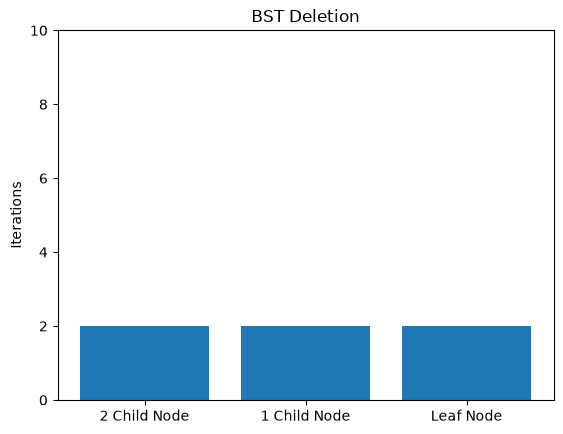

In [39]:
plt.bar(["2 Child Node", "1 Child Node", "Leaf Node",], iter_arr[::-1])
plt.ylim(top=10)
plt.ylabel("Iterations")
plt.title("BST Deletion")
plt.show()

# Q3.

For n=1000,5000,10000, generate three types of input sequences: random, sorted, and reverse-sorted. For each case, build a BST by successive insertions and record: build time, height of the tree, time for 1000 searches, and time for 500 deletions. Tabulate your results and briefly discuss how the input order affects the height and performance of the BST.

## Random

In [40]:
random_data_dict = {}  # Dictionary to store random data for each size
# Generate random data for each size
for i in [1000, 5000, 10000]:
    random_data_dict[i] = random.sample(range(1, i*10), i)  # Generate 'i' unique random numbers

In [41]:
# Random insertions:
build_times_dict = {}  # To store build times for each size
height_dict = {}  # To store heights for each size
bst_trees_dict = {}  # To store the root nodes of BSTs for each size
for i in random_data_dict.keys():
    root_node_temp = None
    build_times = []
    heights = []
    for value in random_data_dict[i]:
        iterations = 0 # Reset iteration count before insertions
        root_node_temp = BST_Insert(value, root_node_temp)
        build_times.append(iterations)  # Store iteration count for each insertion
        heights.append(BST_Height(root_node_temp))  # Store height after each insertion
    bst_trees_dict[i] = root_node_temp  # Store the root node of the BST of size 'i'
    build_times_dict[i] = build_times  # Store iteration counts for building the BST of size 'i'
    height_dict[i] = heights  # Store heights for the BST of size 'i'

In [58]:
random_insertions_df = pd.DataFrame({
    'Input Size (Random Unsorted)': [1000, 5000, 10000],
    'Avg Build Time (Iterations)': [sum(build_times_dict[i])/len(build_times_dict[i]) for i in build_times_dict.keys()],
    'Max Build Time (Iterations)': [max(build_times_dict[i]) for i in build_times_dict.keys()],
    'Min Build Time (Iterations)': [min(build_times_dict[i]) for i in build_times_dict.keys()],
    'Max Height': [max(height_dict[i]) for i in height_dict.keys()],
    'Min Height': [min(height_dict[i]) for i in height_dict.keys()],
    'Avg Height': [sum(height_dict[i])/len(height_dict[i]) for i in height_dict.keys()]
})

In [59]:
random_insertions_df

,Input Size (Random Unsorted),Avg Build Time (Iterations),Max Build Time (Iterations),Min Build Time (Iterations),Max Height,Min Height,Avg Height
0,1000,11.6030,23,0,24,1,19.9420
1,5000,14.5214,28,0,29,1,24.6054
2,10000,16.0780,33,0,34,1,30.1435


In [60]:
random_insertions_df.to_csv('2650026_lab2_data_insertion_random.csv', index=False)

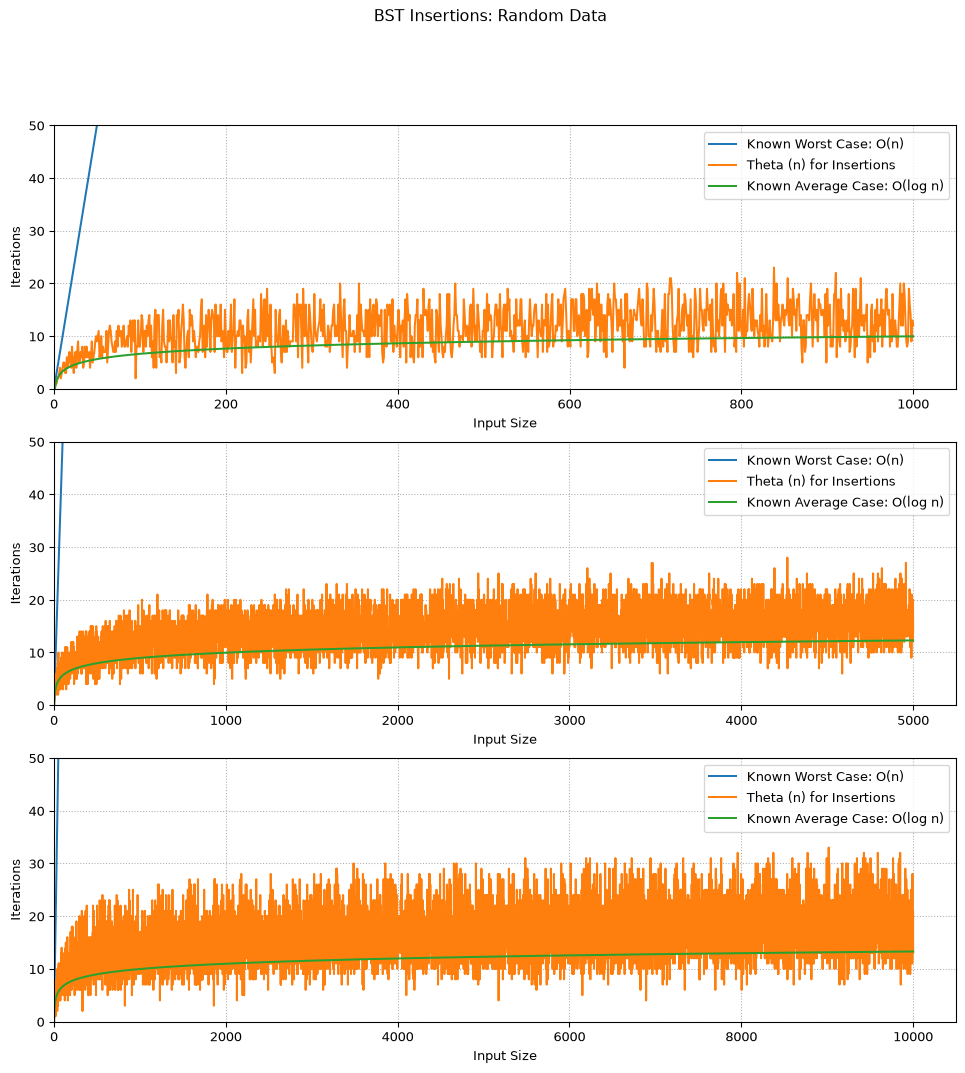

In [61]:
# Plot Graph for Iterations (for Insertion) vs Tree Size
figure(figsize=(12, 12), dpi=97)

# For n=1000
iter_arr = list(build_times_dict[1000])
sizes = [i+1 for i in range(1000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 1)
plt.plot(x, x, label="Known Worst Case: O(n)")
plt.plot(x, y, label="Theta (n) for Insertions")
plt.plot(x, [math.log2(i) for i in x], label="Known Average Case: O(log n)")

plt.xlim(left=0)
plt.ylim(bottom=0, top=50)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.grid(visible=True, linestyle=':')

# For n=5000
iter_arr = list(build_times_dict[5000])
sizes = [i+1 for i in range(5000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 2)
plt.plot(x, x, label="Known Worst Case: O(n)")
plt.plot(x, y, label="Theta (n) for Insertions")
plt.plot(x, [math.log2(i) for i in x], label="Known Average Case: O(log n)")

plt.xlim(left=0)
plt.ylim(bottom=0, top=50)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.grid(visible=True, linestyle=':')

# For n=10000
iter_arr = list(build_times_dict[10000])
sizes = [i+1 for i in range(10000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 3)
plt.plot(x, x, label="Known Worst Case: O(n)")
plt.plot(x, y, label="Theta (n) for Insertions")
plt.plot(x, [math.log2(i) for i in x], label="Known Average Case: O(log n)")

plt.xlim(left=0)
plt.ylim(bottom=0, top=50)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.grid(visible=True, linestyle=':')
plt.suptitle("BST Insertions: Random Data")
plt.show()

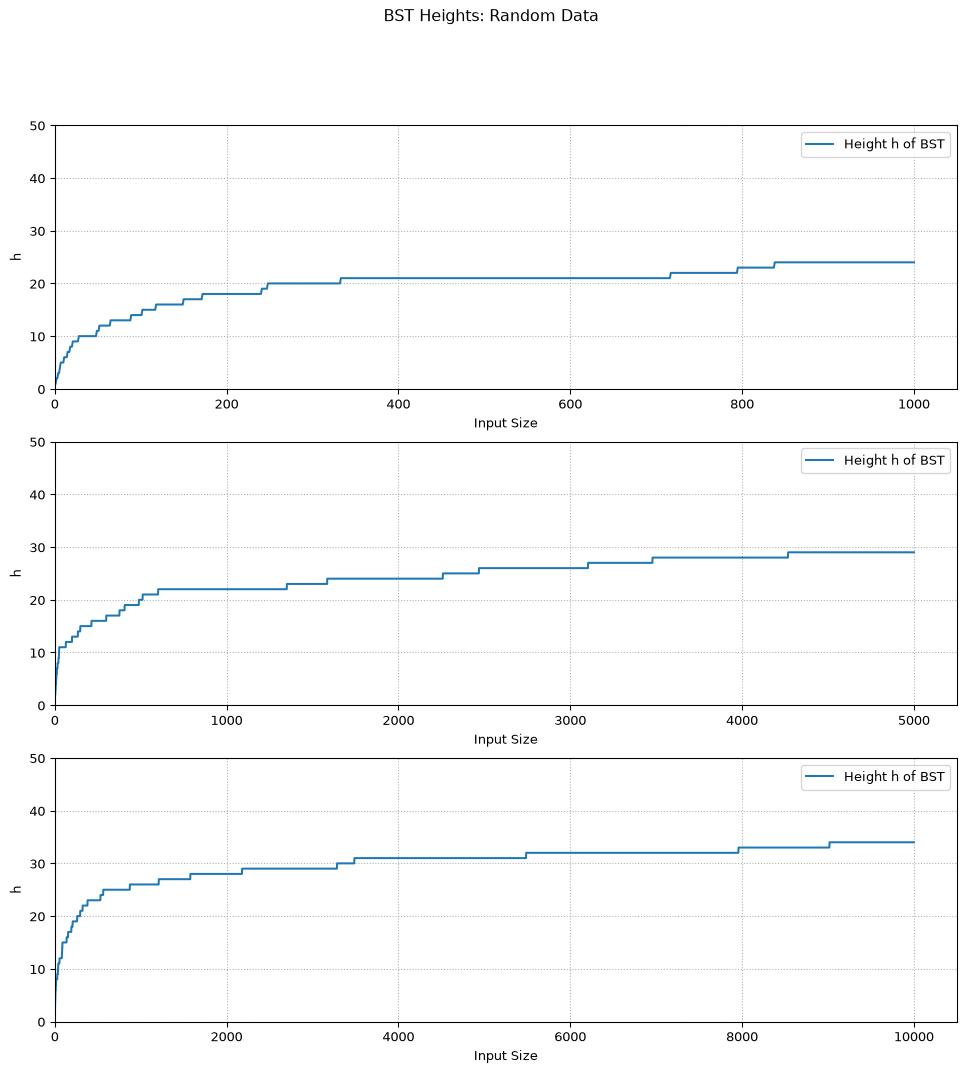

In [62]:
# Plot Graph for Iterations (for Insertion) vs Tree Size
figure(figsize=(12, 12), dpi=97)

# For n=1000
iter_arr = list(height_dict[1000])
sizes = [i+1 for i in range(1000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 1)
plt.plot(x, y, label="Height h of BST")

plt.xlim(left=0)
plt.ylim(bottom=0, top=50)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("h")
plt.grid(visible=True, linestyle=':')

# For n=5000
iter_arr = list(height_dict[5000])
sizes = [i+1 for i in range(5000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 2)
plt.plot(x, y, label="Height h of BST")

plt.xlim(left=0)
plt.ylim(bottom=0, top=50)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("h")
plt.grid(visible=True, linestyle=':')

# For n=10000
iter_arr = list(height_dict[10000])
sizes = [i+1 for i in range(10000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 3)
plt.plot(x, y, label="Height h of BST")

plt.xlim(left=0)
plt.ylim(bottom=0, top=50)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("h")
plt.grid(visible=True, linestyle=':')
plt.suptitle("BST Heights: Random Data")
plt.show()

In [63]:
# 1000 Random Searches:
avg_search_times = []
min_search_times = []
max_search_times = []
search_times_dict = {}  # To store search times for each size
for size in bst_trees_dict.keys():
    search_times = []
    for i in range(1000):
        query = random.randint(1, size*10)  # Generate a random query value
        iterations = 0 # Reset iteration count before searching
        BST_Search(query, bst_trees_dict[size])
        search_times.append(iterations)  # Store iteration count for each search
    search_times_dict[size] = search_times  # Store iteration counts for searches of size
    avg_search_times.append(
        math.fsum(search_times_dict[size]) // len(search_times_dict[size])
    )  # Calculate average search time for this size
    min_search_times.append(
        min(search_times_dict[size])
    )
    max_search_times.append(
        max(search_times_dict[size])
    )

In [66]:
random_searches_df = pd.DataFrame({
    'Input Size (Random Unsorted)': [1000, 5000, 10000],
    'Avg Search Time (Iterations)': avg_search_times,
    'Max Search Time (Iterations)': max_search_times,
    'Min Search Time (Iterations)': min_search_times
})

In [67]:
random_searches_df

,Input Size (Random Unsorted),Avg Search Time (Iterations),Max Search Time (Iterations),Min Search Time (Iterations)
0,1000,13.0,22,4
1,5000,16.0,27,5
2,10000,17.0,33,7


In [68]:
random_searches_df.to_csv('2650026_lab2_data_search_random.csv', index=False)

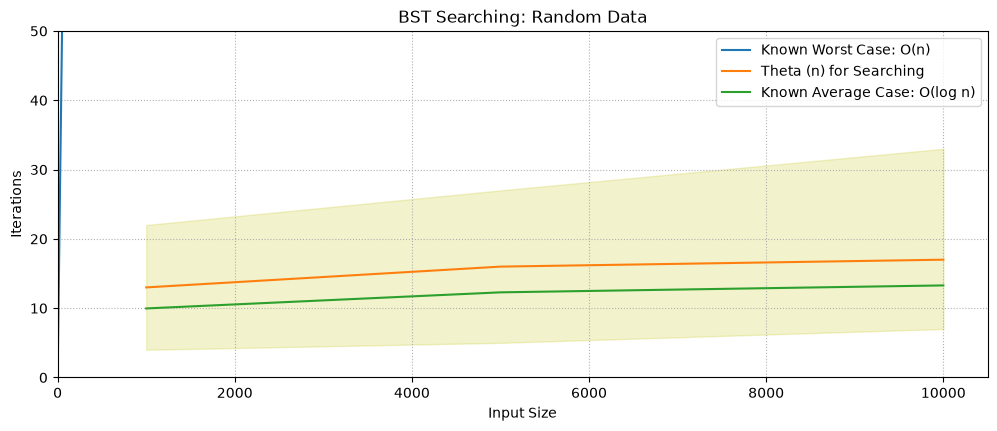

In [69]:
# Plot Graph for Avg (for Insertion) vs Tree Size
x = list(search_times_dict.keys())
y_avg = avg_search_times[:]
y_max = max_search_times[:]
y_min = min_search_times[:]

fig, ax = plt.subplots()
fig.set_figwidth(12)
fig.set_figheight(4.5)

ax.plot([i for i in range(0,100,10)], [i for i in range(0,100,10)], label="Known Worst Case: O(n)")
ax.plot(x, y_avg, '-', label="Theta (n) for Searching")
ax.fill_between(x, y_min, y_max, alpha = 0.2, color='y')
ax.plot(x, [math.log2(i) for i in x], label="Known Average Case: O(log n)")

plt.xlim(left=0)
plt.ylim(bottom=0, top = 50)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.title("BST Searching: Random Data")
plt.grid(visible=True, linestyle=':')
plt.show()

In [70]:
# 500 Deletions:
avg_delete_times = []
min_delete_times = []
max_delete_times = []
delete_times_dict = {}  # To store delete times for each size
for size in bst_trees_dict.keys():
    delete_times = []
    for i in range(500):
        target_value = random.choice(random_data_dict[size])  # Randomly select a value to delete from the original data
        target_node = BST_Search(target_value, bst_trees_dict[size])
        iterations = 0 # Reset iteration count before deletion
        BST_Delete(bst_trees_dict[size], target_node)
        delete_times.append(iterations)  # Store iteration count for each deletion
    delete_times_dict[size] = delete_times  # Store iteration counts for deletions of size
    avg_delete_times.append(
        math.fsum(delete_times_dict[size]) // len(delete_times_dict[size])
    )  # Calculate average delete time for this size
    max_delete_times.append(max(delete_times_dict[size]))
    min_delete_times.append(min(delete_times_dict[size]))

In [71]:
random_deletions_df = pd.DataFrame({
    'Input Size (Random Unsorted)': [1000, 5000, 10000],
    'Avg Delete Time (Iterations)': avg_delete_times,
    'Max Delete Time (Iterations)': max_delete_times,
    'Min Delete Time (Iterations)': min_delete_times
})

In [72]:
random_deletions_df

,Input Size (Random Unsorted),Avg Delete Time (Iterations),Max Delete Time (Iterations),Min Delete Time (Iterations)
0,1000,2.0,12,1
1,5000,2.0,9,1
2,10000,2.0,10,1


In [73]:
random_deletions_df.to_csv('2650026_lab2_data_deletion_random.csv', index=False)

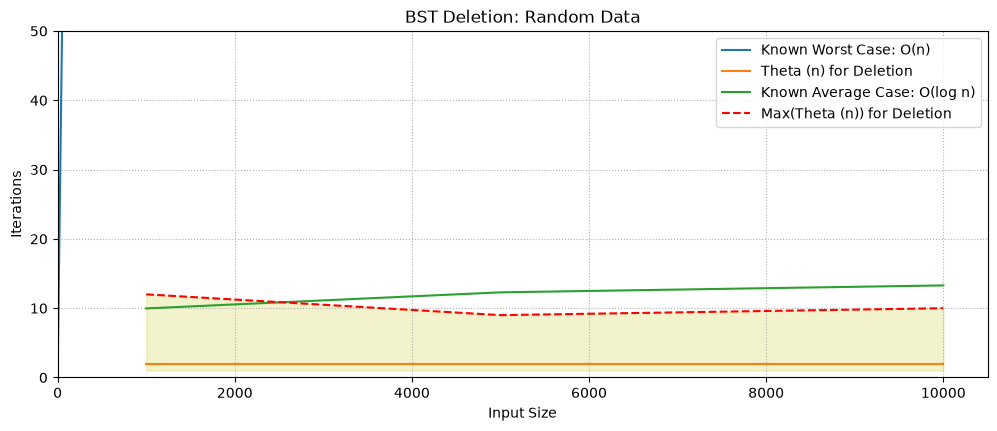

In [75]:
# Plot Graph for Avg (for Insertion) vs Tree Size
x = list(search_times_dict.keys())
y_avg = avg_delete_times[:]
y_max = max_delete_times[:]
y_min = min_delete_times[:]

fig, ax = plt.subplots()
fig.set_figwidth(12)
fig.set_figheight(4.5)

ax.plot([i for i in range(0,100,10)], [i for i in range(0,100,10)], label="Known Worst Case: O(n)")
ax.plot(x, y_avg, '-', label="Theta (n) for Deletion")
ax.fill_between(x, y_min, y_max, alpha = 0.2, color='y')
ax.plot(x, [math.log2(i) for i in x], label="Known Average Case: O(log n)")
ax.plot(x, y_max, '--', label="Max(Theta (n)) for Deletion", color='r')

plt.xlim(left=0)
plt.ylim(bottom=0, top = 50)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.title("BST Deletion: Random Data")
plt.grid(visible=True, linestyle=':')
plt.show()

## Sorted

In [76]:
for i in random_data_dict.keys():
    random_data_dict[i] = sorted(random_data_dict[i])  # Sort the random data for each size

In [77]:
# Random insertions:
build_times_dict = {}  # To store build times for each size
height_dict = {}  # To store heights for each size
bst_trees_dict = {}  # To store the root nodes of BSTs for each size
for i in random_data_dict.keys():
    root_node_temp = None
    build_times = []
    heights = []
    for value in random_data_dict[i]:
        iterations = 0 # Reset iteration count before insertions
        root_node_temp = BST_Insert(value, root_node_temp)
        build_times.append(iterations)  # Store iteration count for each insertion
        heights.append(BST_Height(root_node_temp))  # Store height after each insertion
    bst_trees_dict[i] = root_node_temp  # Store the root node of the BST of size 'i'
    build_times_dict[i] = build_times  # Store iteration counts for building the BST of size 'i'
    height_dict[i] = heights  # Store heights for the BST of size 'i'

In [78]:
sorted_insertions_df = pd.DataFrame({
    'Input Size (Sorted)': [1000, 5000, 10000],
    'Avg Build Time (Iterations)': [sum(build_times_dict[i])/len(build_times_dict[i]) for i in build_times_dict.keys()],
    'Max Build Time (Iterations)': [max(build_times_dict[i]) for i in build_times_dict.keys()],
    'Min Build Time (Iterations)': [min(build_times_dict[i]) for i in build_times_dict.keys()],
    'Max Height': [max(height_dict[i]) for i in height_dict.keys()],
    'Min Height': [min(height_dict[i]) for i in height_dict.keys()],
    'Avg Height': [sum(height_dict[i])/len(height_dict[i]) for i in height_dict.keys()]
})

In [79]:
sorted_insertions_df

,Input Size (Sorted),Avg Build Time (Iterations),Max Build Time (Iterations),Min Build Time (Iterations),Max Height,Min Height,Avg Height
0,1000,499.5,999,0,1000,1,500.5
1,5000,2499.5,4999,0,5000,1,2500.5
2,10000,4999.5,9999,0,10000,1,5000.5


In [85]:
sorted_insertions_df.to_csv('2650026_lab2_data_insertion_sorted.csv', index=False)

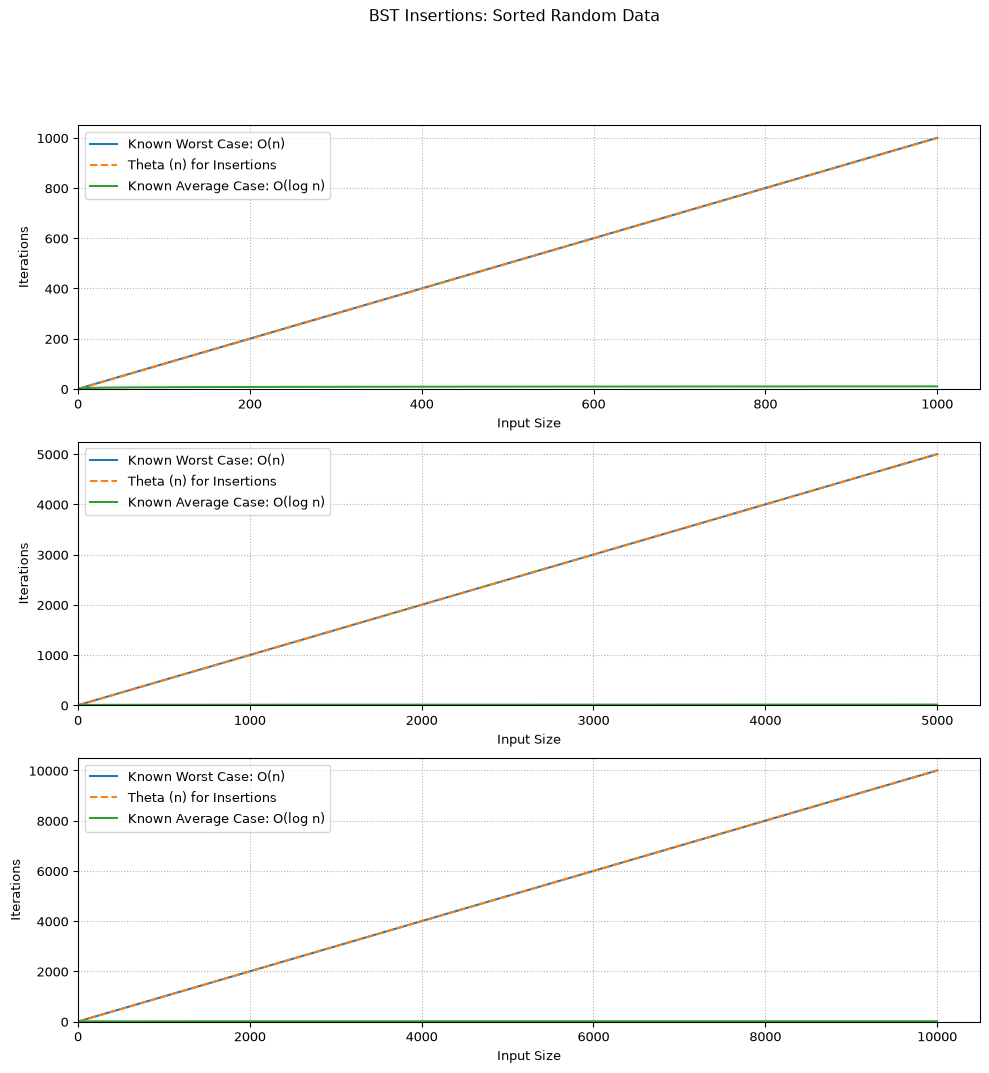

In [80]:
# Plot Graph for Iterations (for Insertion) vs Tree Size
figure(figsize=(12, 12), dpi=97)

# For n=1000
iter_arr = list(build_times_dict[1000])
sizes = [i+1 for i in range(1000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 1)
plt.plot(x, x, label="Known Worst Case: O(n)")
plt.plot(x, y, '--', label="Theta (n) for Insertions")
plt.plot(x, [math.log2(i) for i in x], label="Known Average Case: O(log n)")

plt.xlim(left=0)
plt.ylim(bottom=0,)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.grid(visible=True, linestyle=':')

# For n=5000
iter_arr = list(build_times_dict[5000])
sizes = [i+1 for i in range(5000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 2)
plt.plot(x, x, label="Known Worst Case: O(n)")
plt.plot(x, y, '--', label="Theta (n) for Insertions")
plt.plot(x, [math.log2(i) for i in x], label="Known Average Case: O(log n)")

plt.xlim(left=0)
plt.ylim(bottom=0,)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.grid(visible=True, linestyle=':')

# For n=10000
iter_arr = list(build_times_dict[10000])
sizes = [i+1 for i in range(10000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 3)
plt.plot(x, x, label="Known Worst Case: O(n)")
plt.plot(x, y, '--', label="Theta (n) for Insertions")
plt.plot(x, [math.log2(i) for i in x], label="Known Average Case: O(log n)")

plt.xlim(left=0)
plt.ylim(bottom=0,)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.grid(visible=True, linestyle=':')
plt.suptitle("BST Insertions: Sorted Random Data")
plt.show()

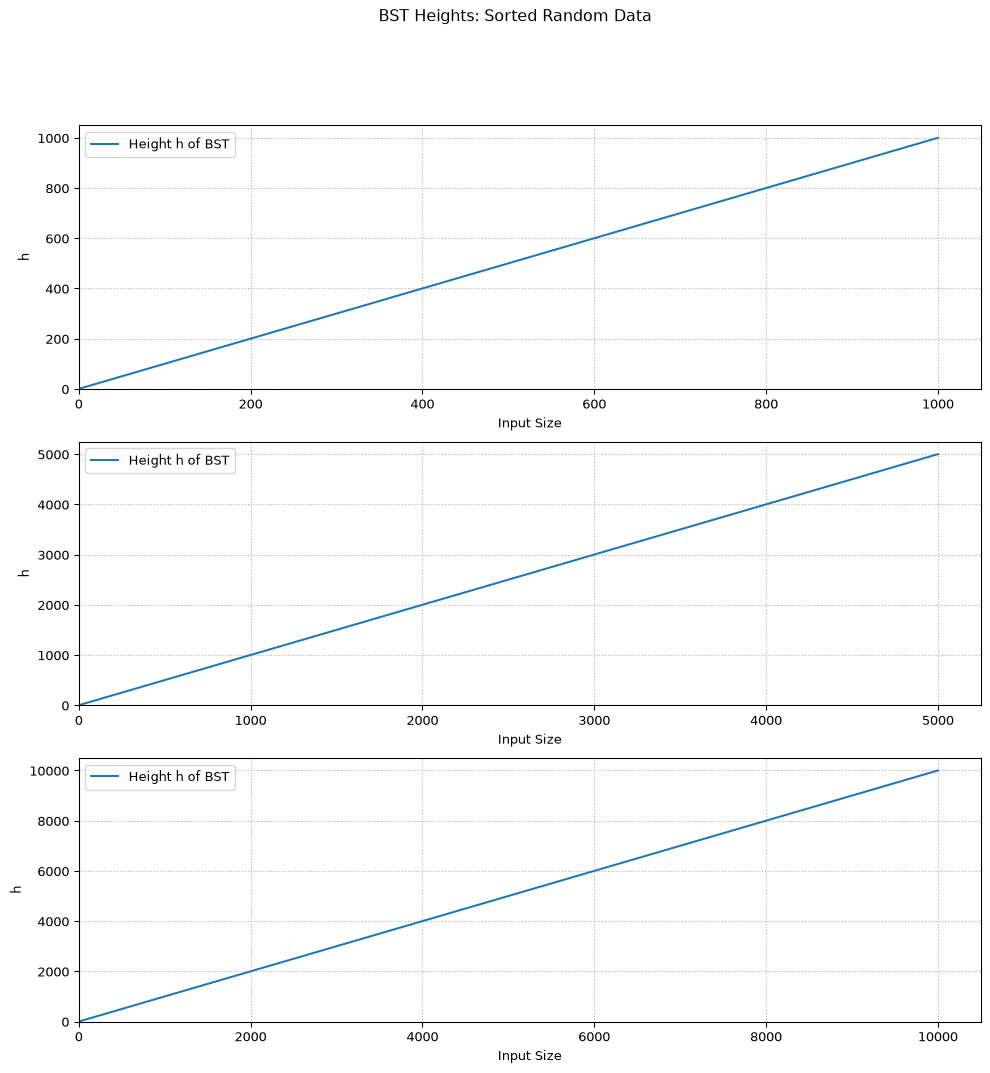

In [81]:
# Plot Graph for Iterations (for Insertion) vs Tree Size
figure(figsize=(12, 12), dpi=97)

# For n=1000
iter_arr = list(height_dict[1000])
sizes = [i+1 for i in range(1000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 1)
plt.plot(x, y, label="Height h of BST")

plt.xlim(left=0)
plt.ylim(bottom=0,)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("h")
plt.grid(visible=True, linestyle=':')

# For n=5000
iter_arr = list(height_dict[5000])
sizes = [i+1 for i in range(5000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 2)
plt.plot(x, y, label="Height h of BST")

plt.xlim(left=0)
plt.ylim(bottom=0,)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("h")
plt.grid(visible=True, linestyle=':')

# For n=10000
iter_arr = list(height_dict[10000])
sizes = [i+1 for i in range(10000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 3)
plt.plot(x, y, label="Height h of BST")

plt.xlim(left=0)
plt.ylim(bottom=0,)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("h")
plt.grid(visible=True, linestyle=':')
plt.suptitle("BST Heights: Sorted Random Data")
plt.show()

In [82]:
# 1000 Random Searches:
avg_search_times = []
min_search_times = []
max_search_times = []
search_times_dict = {}  # To store search times for each size
for size in bst_trees_dict.keys():
    search_times = []
    for i in range(1000):
        query = random.randint(1, size*10)  # Generate a random query value
        iterations = 0 # Reset iteration count before searching
        BST_Search(query, bst_trees_dict[size])
        search_times.append(iterations)  # Store iteration count for each search
    search_times_dict[size] = search_times  # Store iteration counts for searches of size
    avg_search_times.append(
        math.fsum(search_times_dict[size]) // len(search_times_dict[size])
    )  # Calculate average search time for this size
    min_search_times.append(
        min(search_times_dict[size])
    )
    max_search_times.append(
        max(search_times_dict[size])
    )

In [86]:
sorted_random_searches_df = pd.DataFrame({
    'Input Size (Random Unsorted)': [1000, 5000, 10000],
    'Avg Search Time (Iterations)': avg_search_times,
    'Max Search Time (Iterations)': max_search_times,
    'Min Search Time (Iterations)': min_search_times
})

In [87]:
sorted_random_searches_df

,Input Size (Random Unsorted),Avg Search Time (Iterations),Max Search Time (Iterations),Min Search Time (Iterations)
0,1000,502.0,1000,1
1,5000,2432.0,4996,2
2,10000,4946.0,9998,3


In [88]:
sorted_random_searches_df.to_csv('2650026_lab2_data_search_sorted.csv', index=False)

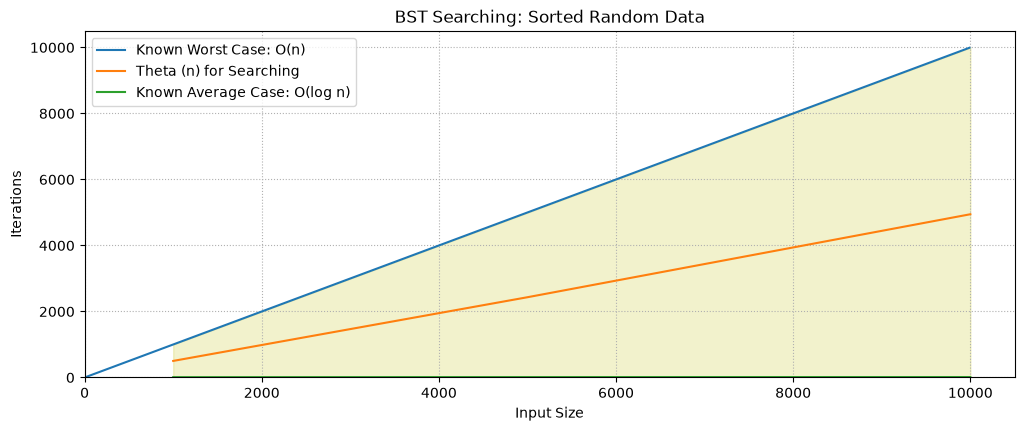

In [89]:
# Plot Graph for Avg (for Insertion) vs Tree Size
x = list(search_times_dict.keys())
y_avg = avg_search_times[:]
y_max = max_search_times[:]
y_min = min_search_times[:]

fig, ax = plt.subplots()
fig.set_figwidth(12)
fig.set_figheight(4.5)

ax.plot([i for i in range(0,10000,10)], [i for i in range(0,10000,10)], label="Known Worst Case: O(n)")
ax.plot(x, y_avg, '-', label="Theta (n) for Searching")
ax.fill_between(x, y_min, y_max, alpha = 0.2, color='y')
ax.plot(x, [math.log2(i) for i in x], label="Known Average Case: O(log n)")

plt.xlim(left=0)
plt.ylim(bottom=0,)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.title("BST Searching: Sorted Random Data")
plt.grid(visible=True, linestyle=':')
plt.show()

In [90]:
# 500 Deletions:
avg_delete_times = []
min_delete_times = []
max_delete_times = []
delete_times_dict = {}  # To store delete times for each size
for size in bst_trees_dict.keys():
    delete_times = []
    for i in range(500):
        target_value = random.choice(random_data_dict[size])  # Randomly select a value to delete from the original data
        target_node = BST_Search(target_value, bst_trees_dict[size])
        iterations = 0 # Reset iteration count before deletion
        BST_Delete(bst_trees_dict[size], target_node)
        delete_times.append(iterations)  # Store iteration count for each deletion
    delete_times_dict[size] = delete_times  # Store iteration counts for deletions of size
    avg_delete_times.append(
        math.fsum(delete_times_dict[size]) // len(delete_times_dict[size])
    )  # Calculate average delete time for this size
    max_delete_times.append(max(delete_times_dict[size]))
    min_delete_times.append(min(delete_times_dict[size]))

In [91]:
sorted_random_deletions_df = pd.DataFrame({
    'Input Size (Random Unsorted)': [1000, 5000, 10000],
    'Avg Delete Time (Iterations)': avg_delete_times,
    'Max Delete Time (Iterations)': max_delete_times,
    'Min Delete Time (Iterations)': min_delete_times
})

In [92]:
sorted_random_deletions_df

,Input Size (Random Unsorted),Avg Delete Time (Iterations),Max Delete Time (Iterations),Min Delete Time (Iterations)
0,1000,1.0,2,1
1,5000,1.0,2,1
2,10000,1.0,2,1


In [94]:
sorted_random_deletions_df.to_csv('2650026_lab2_data_deletion_sorted.csv', index=False)

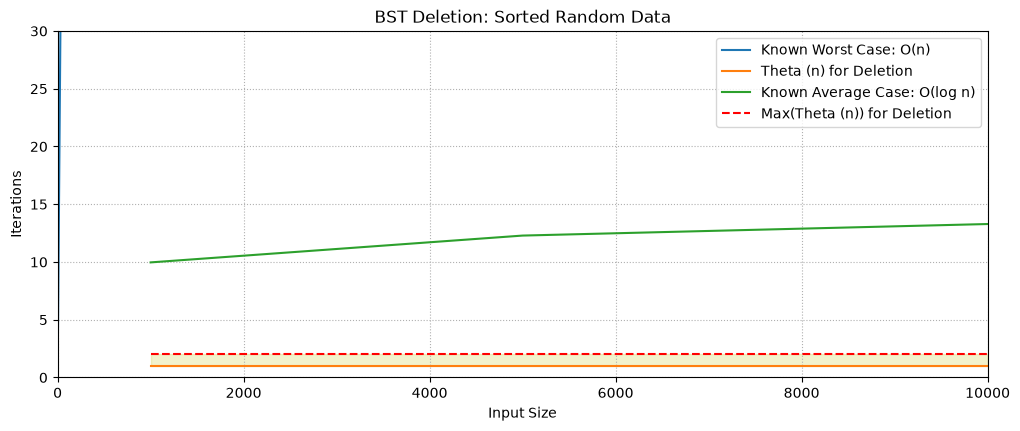

In [95]:
# Plot Graph for Avg (for Insertion) vs Tree Size
x = list(search_times_dict.keys())
y_avg = avg_delete_times[:]
y_max = max_delete_times[:]
y_min = min_delete_times[:]

fig, ax = plt.subplots()
fig.set_figwidth(12)
fig.set_figheight(4.5)

ax.plot([i for i in range(0,10000,10)], [i for i in range(0,10000,10)], label="Known Worst Case: O(n)")
ax.plot(x, y_avg, '-', label="Theta (n) for Deletion")
ax.fill_between(x, y_min, y_max, alpha = 0.2, color='y')
ax.plot(x, [math.log2(i) for i in x], label="Known Average Case: O(log n)")
ax.plot(x, y_max, '--', label="Max(Theta (n)) for Deletion", color='r')

plt.xlim(left=0, right=10000)
plt.ylim(bottom=0, top = 30)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.title("BST Deletion: Sorted Random Data")
plt.grid(visible=True, linestyle=':')
plt.show()

## Reverse Sorted

In [96]:
# Sort the random data for each size in reverse order
for i in random_data_dict.keys():
    random_data_dict[i] = sorted(random_data_dict[i], reverse=True)

In [97]:
# Random insertions:
build_times_dict = {}  # To store build times for each size
height_dict = {}  # To store heights for each size
bst_trees_dict = {}  # To store the root nodes of BSTs for each size
for i in random_data_dict.keys():
    root_node_temp = None
    build_times = []
    heights = []
    for value in random_data_dict[i]:
        iterations = 0 # Reset iteration count before insertions
        root_node_temp = BST_Insert(value, root_node_temp)
        build_times.append(iterations)  # Store iteration count for each insertion
        heights.append(BST_Height(root_node_temp))  # Store height after each insertion
    bst_trees_dict[i] = root_node_temp  # Store the root node of the BST of size 'i'
    build_times_dict[i] = build_times  # Store iteration counts for building the BST of size 'i'
    height_dict[i] = heights  # Store heights for the BST of size 'i'

In [98]:
rev_sorted_insertions_df = pd.DataFrame({
    'Input Size (Reverse Sorted)': [1000, 5000, 10000],
    'Avg Build Time (Iterations)': [sum(build_times_dict[i])/len(build_times_dict[i]) for i in build_times_dict.keys()],
    'Max Build Time (Iterations)': [max(build_times_dict[i]) for i in build_times_dict.keys()],
    'Min Build Time (Iterations)': [min(build_times_dict[i]) for i in build_times_dict.keys()],
    'Max Height': [max(height_dict[i]) for i in height_dict.keys()],
    'Min Height': [min(height_dict[i]) for i in height_dict.keys()],
    'Avg Height': [sum(height_dict[i])/len(height_dict[i]) for i in height_dict.keys()]
})

In [99]:
rev_sorted_insertions_df

,Input Size (Reverse Sorted),Avg Build Time (Iterations),Max Build Time (Iterations),Min Build Time (Iterations),Max Height,Min Height,Avg Height
0,1000,499.5,999,0,1000,1,500.5
1,5000,2499.5,4999,0,5000,1,2500.5
2,10000,4999.5,9999,0,10000,1,5000.5


In [100]:
rev_sorted_insertions_df.to_csv('2650026_lab2_data_insertion_rev_sorted.csv', index=False)

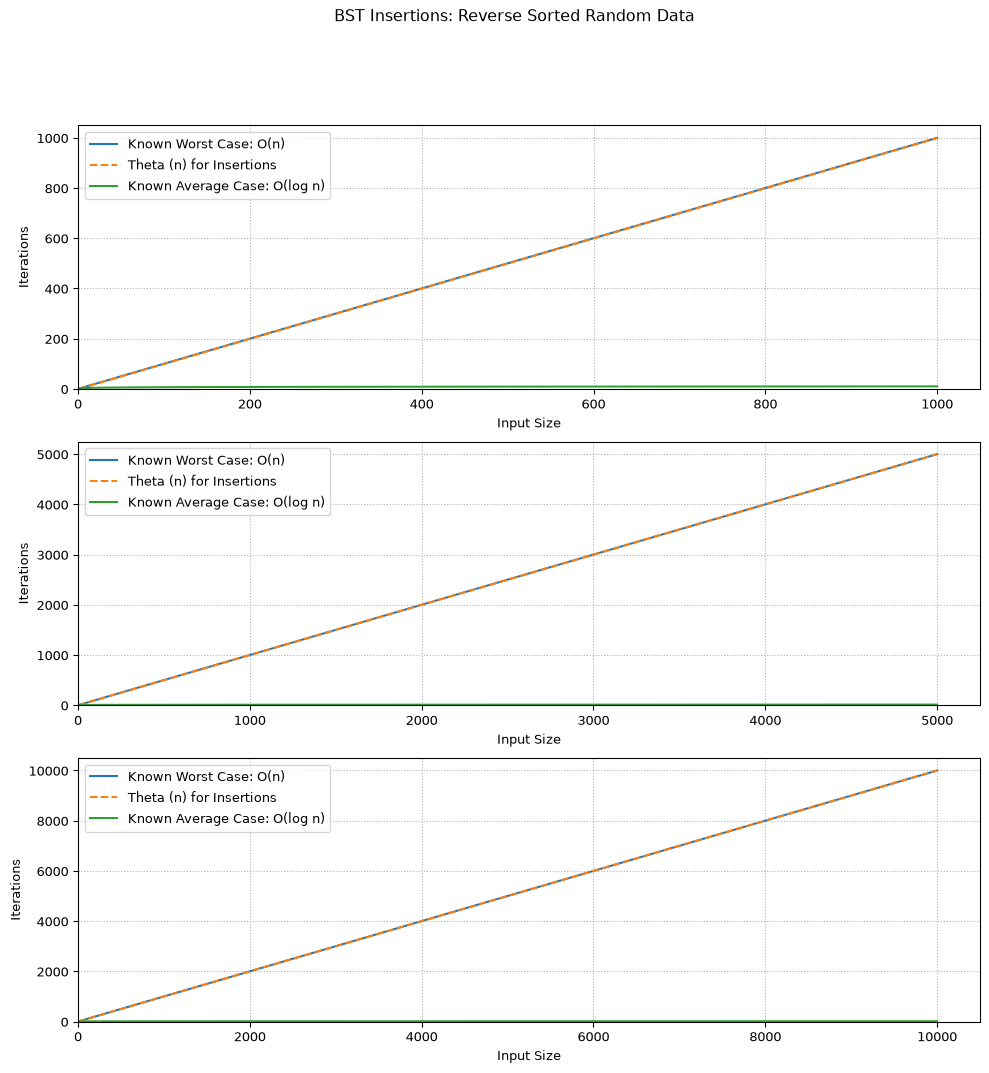

In [101]:
# Plot Graph for Iterations (for Insertion) vs Tree Size
figure(figsize=(12, 12), dpi=97)

# For n=1000
iter_arr = list(build_times_dict[1000])
sizes = [i+1 for i in range(1000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 1)
plt.plot(x, x, label="Known Worst Case: O(n)")
plt.plot(x, y, '--', label="Theta (n) for Insertions")
plt.plot(x, [math.log2(i) for i in x], label="Known Average Case: O(log n)")

plt.xlim(left=0)
plt.ylim(bottom=0,)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.grid(visible=True, linestyle=':')

# For n=5000
iter_arr = list(build_times_dict[5000])
sizes = [i+1 for i in range(5000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 2)
plt.plot(x, x, label="Known Worst Case: O(n)")
plt.plot(x, y, '--', label="Theta (n) for Insertions")
plt.plot(x, [math.log2(i) for i in x], label="Known Average Case: O(log n)")

plt.xlim(left=0)
plt.ylim(bottom=0,)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.grid(visible=True, linestyle=':')

# For n=10000
iter_arr = list(build_times_dict[10000])
sizes = [i+1 for i in range(10000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 3)
plt.plot(x, x, label="Known Worst Case: O(n)")
plt.plot(x, y, '--', label="Theta (n) for Insertions")
plt.plot(x, [math.log2(i) for i in x], label="Known Average Case: O(log n)")

plt.xlim(left=0)
plt.ylim(bottom=0,)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.grid(visible=True, linestyle=':')
plt.suptitle("BST Insertions: Reverse Sorted Random Data")
plt.show()

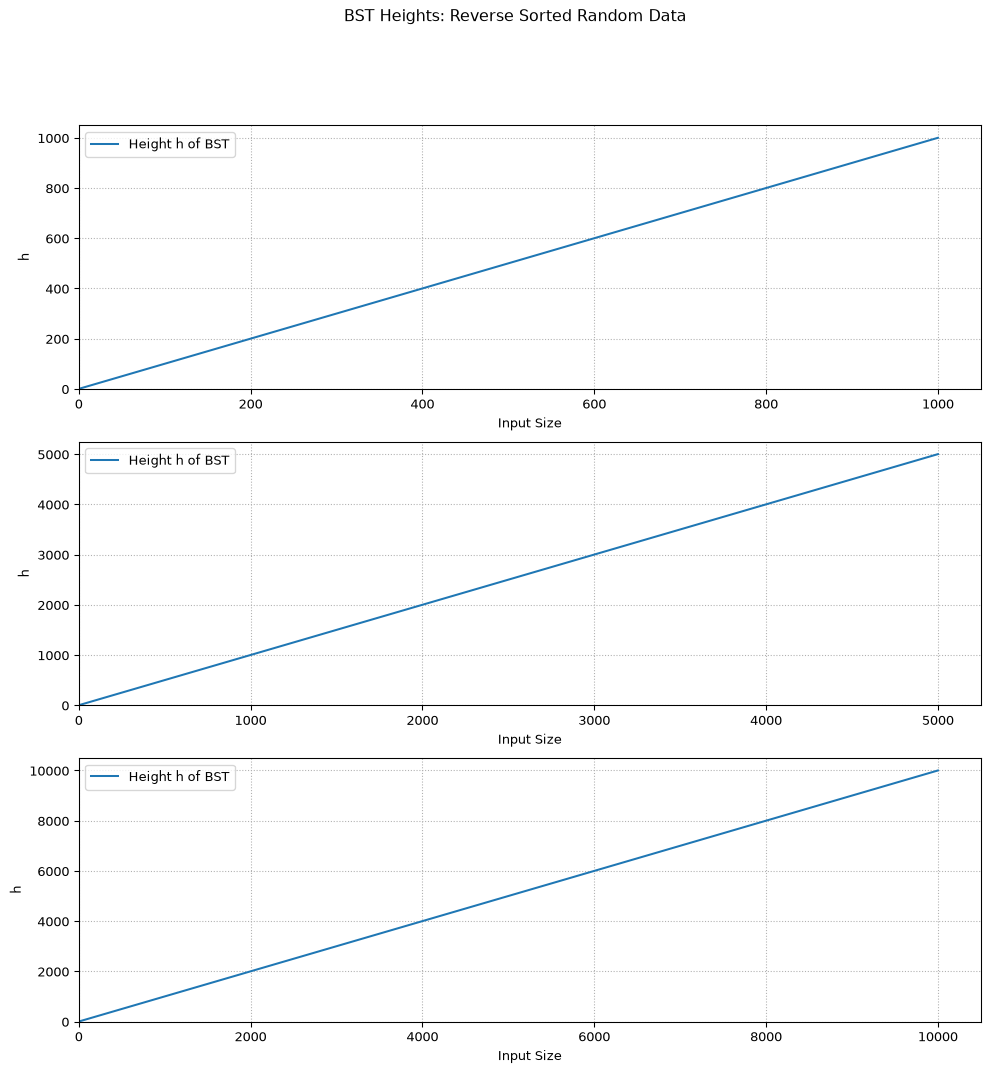

In [102]:
# Plot Graph for Height vs Tree Size
figure(figsize=(12, 12), dpi=97)

# For n=1000
iter_arr = list(height_dict[1000])
sizes = [i+1 for i in range(1000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 1)
plt.plot(x, y, label="Height h of BST")

plt.xlim(left=0)
plt.ylim(bottom=0,)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("h")
plt.grid(visible=True, linestyle=':')

# For n=5000
iter_arr = list(height_dict[5000])
sizes = [i+1 for i in range(5000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 2)
plt.plot(x, y, label="Height h of BST")

plt.xlim(left=0)
plt.ylim(bottom=0,)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("h")
plt.grid(visible=True, linestyle=':')

# For n=10000
iter_arr = list(height_dict[10000])
sizes = [i+1 for i in range(10000)]

x = sizes[:]
y = iter_arr[:]

plt.subplot(3, 1, 3)
plt.plot(x, y, label="Height h of BST")

plt.xlim(left=0)
plt.ylim(bottom=0,)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("h")
plt.grid(visible=True, linestyle=':')
plt.suptitle("BST Heights: Reverse Sorted Random Data")
plt.show()

In [103]:
# 1000 Random Searches:
avg_search_times = []
min_search_times = []
max_search_times = []
search_times_dict = {}  # To store search times for each size
for size in bst_trees_dict.keys():
    search_times = []
    for i in range(1000):
        query = random.randint(1, size*10)  # Generate a random query value
        iterations = 0 # Reset iteration count before searching
        BST_Search(query, bst_trees_dict[size])
        search_times.append(iterations)  # Store iteration count for each search
    search_times_dict[size] = search_times  # Store iteration counts for searches of size
    avg_search_times.append(
        math.fsum(search_times_dict[size]) // len(search_times_dict[size])
    )  # Calculate average search time for this size
    min_search_times.append(
        min(search_times_dict[size])
    )
    max_search_times.append(
        max(search_times_dict[size])
    )

In [104]:
rev_sorted_searches_df = pd.DataFrame({
    'Input Size (Reverse Sorted)': [1000, 5000, 10000],
    'Avg Search Time (Iterations)': avg_search_times,
    'Max Search Time (Iterations)': max_search_times,
    'Min Search Time (Iterations)': min_search_times
})

In [105]:
rev_sorted_insertions_df

,Input Size (Reverse Sorted),Avg Build Time (Iterations),Max Build Time (Iterations),Min Build Time (Iterations),Max Height,Min Height,Avg Height
0,1000,499.5,999,0,1000,1,500.5
1,5000,2499.5,4999,0,5000,1,2500.5
2,10000,4999.5,9999,0,10000,1,5000.5


In [106]:
rev_sorted_insertions_df.to_csv('2650026_lab2_data_search_rev_sorted.csv', index=False)

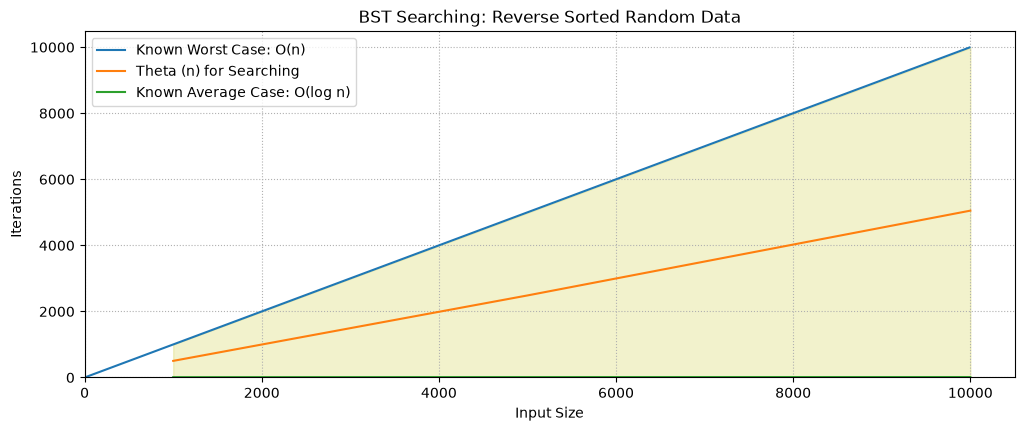

In [107]:
# Plot Graph for Avg (for Insertion) vs Tree Size
x = list(search_times_dict.keys())
y_avg = avg_search_times[:]
y_max = max_search_times[:]
y_min = min_search_times[:]

fig, ax = plt.subplots()
fig.set_figwidth(12)
fig.set_figheight(4.5)

ax.plot([i for i in range(0,10000,10)], [i for i in range(0,10000,10)], label="Known Worst Case: O(n)")
ax.plot(x, y_avg, '-', label="Theta (n) for Searching")
ax.fill_between(x, y_min, y_max, alpha = 0.2, color='y')
ax.plot(x, [math.log2(i) for i in x], label="Known Average Case: O(log n)")

plt.xlim(left=0)
plt.ylim(bottom=0,)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.title("BST Searching: Reverse Sorted Random Data")
plt.grid(visible=True, linestyle=':')
plt.show()

In [108]:
# 500 Deletions:
avg_delete_times = []
min_delete_times = []
max_delete_times = []
delete_times_dict = {}  # To store delete times for each size
for size in bst_trees_dict.keys():
    delete_times = []
    for i in range(500):
        target_value = random.choice(random_data_dict[size])  # Randomly select a value to delete from the original data
        target_node = BST_Search(target_value, bst_trees_dict[size])
        iterations = 0 # Reset iteration count before deletion
        BST_Delete(bst_trees_dict[size], target_node)
        delete_times.append(iterations)  # Store iteration count for each deletion
    delete_times_dict[size] = delete_times  # Store iteration counts for deletions of size
    avg_delete_times.append(
        math.fsum(delete_times_dict[size]) // len(delete_times_dict[size])
    )  # Calculate average delete time for this size
    max_delete_times.append(max(delete_times_dict[size]))
    min_delete_times.append(min(delete_times_dict[size]))

In [109]:
rev_sorted_deletions_df = pd.DataFrame({
    'Input Size (Reverse Sorted)': [1000, 5000, 10000],
    'Avg Delete Time (Iterations)': avg_delete_times,
    'Max Delete Time (Iterations)': max_delete_times,
    'Min Delete Time (Iterations)': min_delete_times
})

In [111]:
rev_sorted_deletions_df

,Input Size (Reverse Sorted),Avg Delete Time (Iterations),Max Delete Time (Iterations),Min Delete Time (Iterations)
0,1000,1.0,2,1
1,5000,1.0,2,1
2,10000,1.0,2,1


In [112]:
rev_sorted_deletions_df.to_csv('2650026_lab2_data_deletion_rev_sorted.csv', index=False)

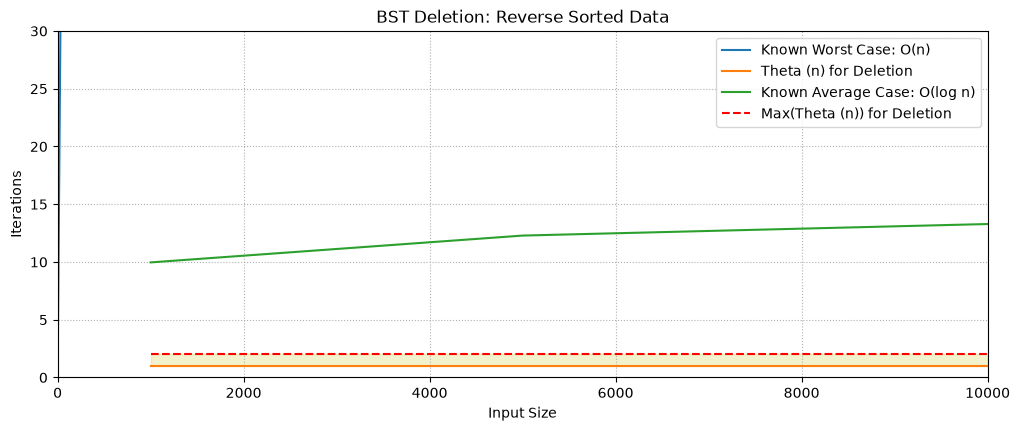

In [113]:
# Plot Graph for Avg (for Deletions) vs Tree Size
x = list(search_times_dict.keys())
y_avg = avg_delete_times[:]
y_max = max_delete_times[:]
y_min = min_delete_times[:]

fig, ax = plt.subplots()
fig.set_figwidth(12)
fig.set_figheight(4.5)

ax.plot([i for i in range(0,10000,10)], [i for i in range(0,10000,10)], label="Known Worst Case: O(n)")
ax.plot(x, y_avg, '-', label="Theta (n) for Deletion")
ax.fill_between(x, y_min, y_max, alpha = 0.2, color='y')
ax.plot(x, [math.log2(i) for i in x], label="Known Average Case: O(log n)")
ax.plot(x, y_max, '--', label="Max(Theta (n)) for Deletion", color='r')

plt.xlim(left=0, right=10000)
plt.ylim(bottom=0, top = 30)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("Iterations")
plt.title("BST Deletion: Reverse Sorted Data")
plt.grid(visible=True, linestyle=':')
plt.show()